# DirectLiNGAM using GPU

## Preparing to Use the GPU Version of DirectLiNGAM

> **Important**
>
> The instructions in this notebook have been validated using our fork of **culingam**:
>
> https://github.com/ikeuchi-screen/culingam
>
> Please use this repository rather than the original `aknvictor/culingam` repository.

Before installing the GPU-enabled version of DirectLiNGAM, you must identify your GPU architecture and configure the appropriate build environment.

### Identify Your GPU Architecture

The recommended method is to use `nvidia-smi`.

Recent NVIDIA drivers can report both the GPU name and Compute Capability directly:

```bash
nvidia-smi --query-gpu=name,compute_cap --format=csv,noheader
```

**Example output:**
```
NVIDIA GeForce RTX 4090, 8.9
```

* **GPU**: RTX 4090
* **Compute Capability**: 8.9
* **Architecture**: sm_89

If only the GPU model name is available, you can find the corresponding Compute Capability from [NVIDIA's official CUDA GPU list](https://developer.nvidia.com/cuda/gpus).



### Linux Installation

1. Clone the `culingam` repository.

```bash
git clone https://github.com/ikeuchi-screen/culingam
cd culingam
```

2. Set the `CUDA_HOME` environment variable to your CUDA Toolkit installation path.

```bash
export CUDA_HOME=/usr/local/cuda-12.6
```

3. Set the `GPU_ARCH` environment variable to match your GPU architecture.

```bash
export GPU_ARCH=sm_89
```

4. Install the package.

```bash
pip install .
```

### Windows Installation

1. Clone the `culingam` repository.

```bat
git clone https://github.com/ikeuchi-screen/culingam
cd culingam
```

2. Set the `CUDA_HOME` environment variable to your CUDA Toolkit installation path.

```bat
set CUDA_HOME=C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.6
```

3. Set the `GPU_ARCH` environment variable to match your GPU architecture.

```bat
set GPU_ARCH=sm_89
```

4. Install the package. The `--no-build-isolation` option is recommended because it allows the build process to access the CUDA-related environment variables and dependencies available in the current Python environment.

```bash
pip install -v --no-build-isolation .
```



## Import and settings
In this example, we need to import `numpy`, `pandas`, and `graphviz` in addition to `lingam`.

In [1]:
import numpy as np
import pandas as pd
import graphviz
import lingam
from lingam.utils import print_causal_directions, print_dagc, make_dot, evaluate_model_fit

import warnings
warnings.filterwarnings("ignore")

print([np.__version__, pd.__version__, graphviz.__version__, lingam.__version__])

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

['2.2.6', '3.0.5', '0.21', '1.13.0']


## Test data
We create test data consisting of 6 variables.

In [2]:
x3 = np.random.uniform(size=1000)
x0 = 3.0*x3 + np.random.uniform(size=1000)
x2 = 6.0*x3 + np.random.uniform(size=1000)
x1 = 3.0*x0 + 2.0*x2 + np.random.uniform(size=1000)
x5 = 4.0*x0 + np.random.uniform(size=1000)
x4 = 8.0*x0 - 1.0*x2 + np.random.uniform(size=1000)
X = pd.DataFrame(np.array([x0, x1, x2, x3, x4, x5]).T ,columns=['x0', 'x1', 'x2', 'x3', 'x4', 'x5'])
X.head()

,x0,x1,x2,x3,x4,x5
0,1.308753,9.616856,2.508946,0.374540,8.354715,5.807009
1,3.394044,22.881342,5.951265,0.950714,21.674522,14.381608
2,3.068928,20.053687,5.298218,0.731994,20.107750,13.035872
3,2.528200,15.892469,3.841497,0.598658,16.724110,10.266701
4,1.274617,6.811720,1.208062,0.156019,9.858525,5.247718


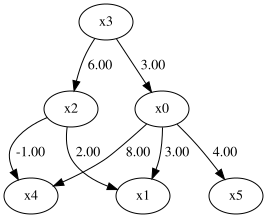

In [3]:
m = np.array([[0.0, 0.0, 0.0, 3.0, 0.0, 0.0],
              [3.0, 0.0, 2.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 6.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [8.0, 0.0,-1.0, 0.0, 0.0, 0.0],
              [4.0, 0.0, 0.0, 0.0, 0.0, 0.0]])

dot = make_dot(m)

# Save pdf
dot.render('dag')

# Save png
dot.format = 'png'
dot.render('dag')

dot

## Causal Discovery using GPU
To run causal discovery, we create a `DirectLiNGAM` object and call the `fit` method. 

**When using GPU acceleration,** instantiate the model with the option `measure='pwling_fast'`.

In [4]:
model = lingam.DirectLiNGAM(measure='pwling_fast')
model.fit(X)

Using the `causal_order_` properties, we can see the causal ordering as a result of the causal discovery.

In [5]:
model.causal_order_

[np.int32(3), np.int32(2), np.int32(0), np.int32(4), np.int32(5), np.int32(1)]

Also, using the `adjacency_matrix_` properties, we can see the adjacency matrix as a result of the causal discovery.

In [6]:
model.adjacency_matrix_

array([[ 0.   ,  0.   ,  0.   ,  3.029,  0.   ,  0.   ],
       [ 2.999,  0.   ,  1.995,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  6.014,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 8.03 ,  0.   , -1.025,  0.   ,  0.   ,  0.   ],
       [ 4.013,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ]])

We can draw a causal graph by utility funciton.

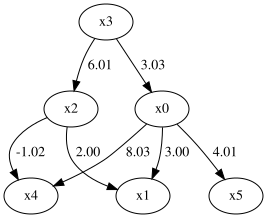

In [7]:
make_dot(model.adjacency_matrix_)

## Independence between error variables
To check if the LiNGAM assumption is broken, we can get p-values of independence between error variables. The value in the i-th row and j-th column of the obtained matrix shows the p-value of the independence of the error variables $e_i$ and $e_j$.

In [8]:
p_values = model.get_error_independence_p_values(X)
print(p_values)

[[0.    0.76  0.377 0.672 0.446 0.087]
 [0.76  0.    0.792 0.423 0.253 0.15 ]
 [0.377 0.792 0.    0.941 0.477 0.445]
 [0.672 0.423 0.941 0.    0.369 0.529]
 [0.446 0.253 0.477 0.369 0.    0.545]
 [0.087 0.15  0.445 0.529 0.545 0.   ]]


In [9]:
evaluate_model_fit(model.adjacency_matrix_, X)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,9,16,7.581987,0.576757,23272.542135,1.000061,0.999674,0.999421,0.999674,1.000108,0,23.984836,82.877899,0.007582


## Bootstrapping using GPU
We call `bootstrap()` method instead of `fit()`. Here, the second argument specifies the number of bootstrap sampling.

**When using GPU acceleration,** instantiate the model with the option `measure='pwling_fast'`.

In [10]:
n_samples = 1000

model = lingam.DirectLiNGAM(measure='pwling_fast')
result = model.bootstrap(X, n_sampling=n_samples)

## Causal Directions
Since `BootstrapResult` object is returned, we can get the ranking of the causal directions extracted by `get_causal_direction_counts()` method. In the following sample code, `n_directions` option is limited to the causal directions of the top 8 rankings, and `min_causal_effect` option is limited to causal directions with a coefficient of 0.01 or more.

In [11]:
cdc = result.get_causal_direction_counts(n_directions=8, min_causal_effect=0.01, split_by_causal_effect_sign=True)

We can check the result by utility function.

In [12]:
print_causal_directions(cdc, n_samples)

x1 <--- x0 (b>0) (100.0%)
x1 <--- x2 (b>0) (100.0%)
x5 <--- x0 (b>0) (100.0%)
x2 <--- x3 (b>0) (99.7%)
x4 <--- x2 (b<0) (98.4%)
x0 <--- x3 (b>0) (97.6%)
x4 <--- x0 (b>0) (97.4%)
x1 <--- x5 (b<0) (10.9%)


## Directed Acyclic Graphs
Also, using the `get_directed_acyclic_graph_counts()` method, we can get the ranking of the DAGs extracted. In the following sample code, `n_dags` option is limited to the dags of the top 3 rankings, and `min_causal_effect` option is limited to causal directions with a coefficient of 0.01 or more.

In [13]:
dagc = result.get_directed_acyclic_graph_counts(n_dags=3, min_causal_effect=0.01, split_by_causal_effect_sign=True)

We can check the result by utility function.

In [14]:
print_dagc(dagc, n_samples)

DAG[0]: 67.8%
	x0 <--- x3 (b>0)
	x1 <--- x0 (b>0)
	x1 <--- x2 (b>0)
	x2 <--- x3 (b>0)
	x4 <--- x0 (b>0)
	x4 <--- x2 (b<0)
	x5 <--- x0 (b>0)
DAG[1]: 7.7%
	x0 <--- x3 (b>0)
	x1 <--- x0 (b>0)
	x1 <--- x2 (b>0)
	x1 <--- x5 (b<0)
	x2 <--- x3 (b>0)
	x4 <--- x0 (b>0)
	x4 <--- x2 (b<0)
	x5 <--- x0 (b>0)
DAG[2]: 4.2%
	x0 <--- x3 (b>0)
	x1 <--- x0 (b>0)
	x1 <--- x2 (b>0)
	x2 <--- x3 (b>0)
	x4 <--- x0 (b>0)
	x4 <--- x2 (b<0)
	x4 <--- x5 (b<0)
	x5 <--- x0 (b>0)


## Probability
Using the `get_probabilities()` method, we can get the probability of bootstrapping.

In [15]:
prob = result.get_probabilities(min_causal_effect=0.01)
print(prob)

[[0.    0.    0.057 0.976 0.026 0.   ]
 [1.    0.    1.    0.008 0.065 0.109]
 [0.008 0.    0.    0.997 0.003 0.   ]
 [0.    0.    0.003 0.    0.    0.   ]
 [0.974 0.008 0.984 0.036 0.    0.058]
 [1.    0.002 0.046 0.011 0.036 0.   ]]


## Total Causal Effects
Using the `get_total_causal_effects()` method, we can get the list of total causal effect. The total causal effects we can get are dictionary type variable.
We can display the list nicely by assigning it to pandas.DataFrame. Also, we have replaced the variable index with a label below.

In [16]:
causal_effects = result.get_total_causal_effects(min_causal_effect=0.01)

# Assign to pandas.DataFrame for pretty display
df = pd.DataFrame(causal_effects)
labels = [f'x{i}' for i in range(X.shape[1])]
df['from'] = df['from'].apply(lambda x : labels[x])
df['to'] = df['to'].apply(lambda x : labels[x])
df

,from,to,effect,probability
0,x3,x0,3.030269,1.000
1,x0,x1,3.001860,1.000
2,x3,x1,21.090294,1.000
3,x2,x1,1.995733,1.000
4,x3,x4,18.171285,1.000
5,x0,x5,4.013368,1.000
6,x3,x5,12.157223,1.000
7,x3,x2,6.014649,0.997
8,x2,x4,-1.025236,0.984
9,x0,x4,8.032282,0.974


We can easily perform sorting operations with pandas.DataFrame.

In [17]:
df.sort_values('effect', ascending=False).head()

,from,to,effect,probability
2,x3,x1,21.090294,1.000
4,x3,x4,18.171285,1.000
6,x3,x5,12.157223,1.000
9,x0,x4,8.032282,0.974
7,x3,x2,6.014649,0.997


In [18]:
df.sort_values('probability', ascending=True).head()

,from,to,effect,probability
21,x1,x5,-0.090495,0.002
19,x2,x3,0.163980,0.003
20,x4,x2,-0.012233,0.003
17,x0,x2,0.092491,0.008
18,x1,x4,0.094129,0.008


And with pandas.DataFrame, we can easily filter by keywords. The following code extracts the causal direction towards x1.

In [19]:
df[df['to']=='x1'].head()

,from,to,effect,probability
1,x0,x1,3.001860,1.000
2,x3,x1,21.090294,1.000
3,x2,x1,1.995733,1.000
10,x5,x1,-0.096742,0.109
12,x4,x1,0.098537,0.093


Because it holds the raw data of the total causal effect (the original data for calculating the median), it is possible to draw a histogram of the values of the causal effect, as shown below.

(array([  5.,  22.,  74., 148., 216., 268., 157.,  78.,  26.,   6.]),
 array([2.931, 2.951, 2.97 , 2.989, 3.009, 3.028, 3.047, 3.067, 3.086,
        3.105, 3.124]),
 <BarContainer object of 10 artists>)

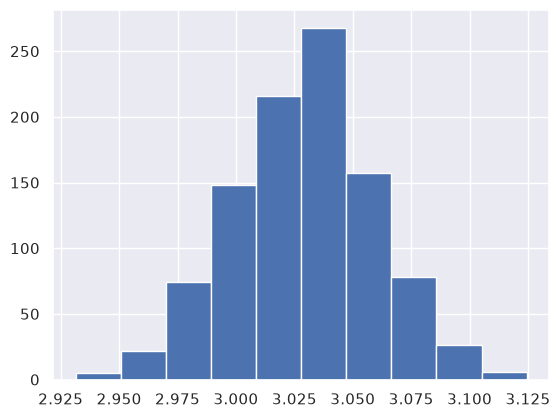

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline

from_index = 3 # index of x3
to_index = 0 # index of x0
plt.hist(result.total_effects_[:, to_index, from_index])

## Bootstrap Probability of Path
Using the `get_paths()` method, we can explore all paths from any variable to any variable and calculate the bootstrap probability for each path. The path will be output as an array of variable indices. For example, the array `[3, 0, 1]` shows the path from variable X3 through variable X0 to variable X1.

In [21]:
from_index = 3 # index of x3
to_index = 1 # index of x1

pd.DataFrame(result.get_paths(from_index, to_index))

,path,effect,probability
0,"[3, 2, 1]",12.008340,0.997
1,"[3, 0, 1]",9.087017,0.976
2,"[3, 0, 5, 1]",-1.191347,0.108
3,"[3, 0, 4, 1]",2.306179,0.064
4,"[3, 2, 4, 1]",-0.577927,0.064
5,"[3, 2, 0, 1]",1.883982,0.057
6,"[3, 4, 0, 1]",6.864029,0.026
7,"[3, 2, 4, 0, 1]",-1.903159,0.010
8,"[3, 1]",0.592553,0.008
9,"[3, 0, 2, 1]",0.568672,0.008
